In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!pip install yellowbrick

In [4]:
import pyreadr

result = pyreadr.read_r("data_GPS.rds")
df = result[None]  # None = clé par défaut pour un objet RDS unique

In [5]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score 

In [6]:
#data = df.to_numpy()
df_quanti = df.select_dtypes(include='number')
data = df_quanti.to_numpy()

In [7]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
data_scaled = ss.fit_transform(data)

In [8]:
from sklearn.decomposition import PCA

pca = PCA()
data_pca = pca.fit_transform(data_scaled)

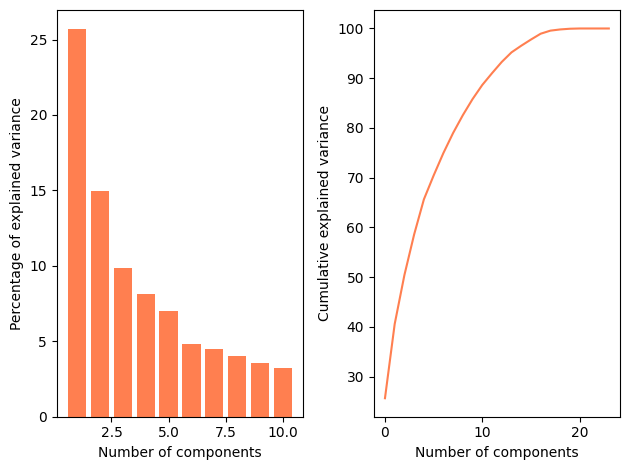

Variance explained by the first 9 components: 82.57


In [9]:
explained_variance_ratio = 100*pca.explained_variance_ratio_

plt.subplot(1,2,1)
n_bars = 10
plt.bar(np.arange(1, n_bars+1), explained_variance_ratio[:n_bars], color='coral')
plt.xlabel("Number of components")
plt.ylabel("Percentage of explained variance")

plt.subplot(1,2,2)
plt.plot(np.cumsum(explained_variance_ratio), color='coral')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance');

plt.tight_layout()
plt.show()

print("Variance explained by the first 9 components:", round(sum([explained_variance_ratio[i] for i in range(9)]),2))

In [10]:
data_reduced = data_pca[:,:9]

In [11]:
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

YellowbrickTypeError: Cannot detect the model name for non estimator: '<class 'numpy.ndarray'>'

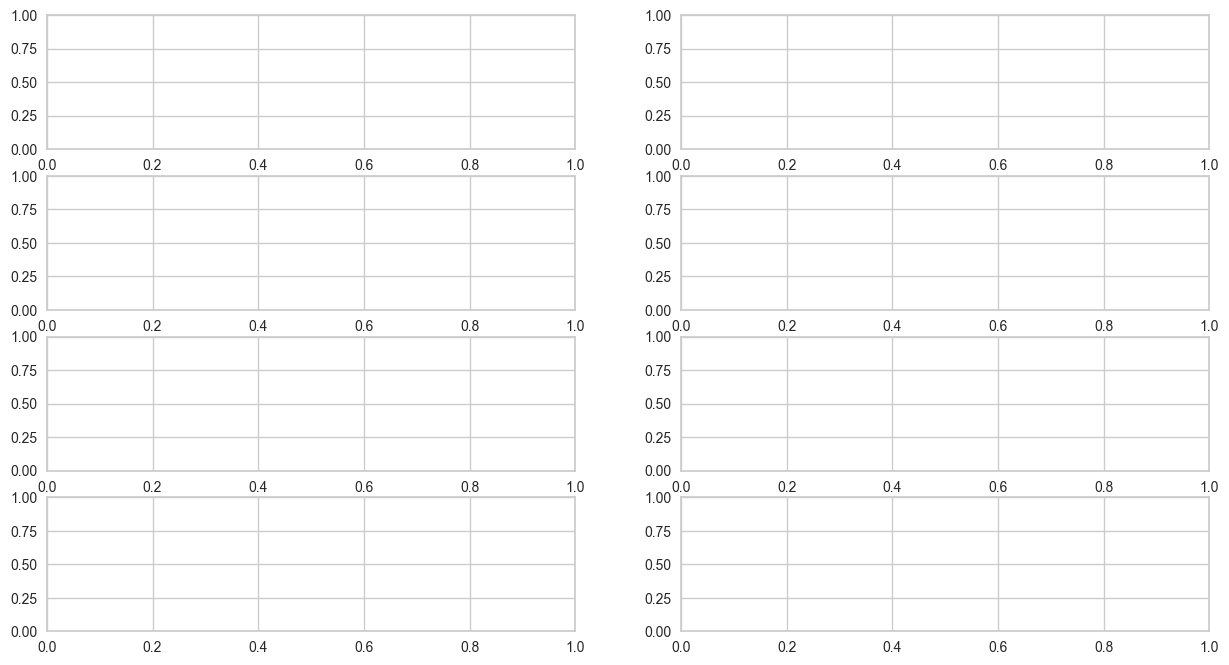

In [12]:
fig, ax = plt.subplots(4, 2, figsize=(15,8))

for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, n_init=3)
    clusters_gmm = gmm.fit_predict(data_reduced)
    q, mod = divmod(k, 2)
   
    visualizer = SilhouetteVisualizer(clusters_gmm, colors='yellowbrick', ax=ax[q-1][mod],force_model=True)
    visualizer.fit(data_reduced)

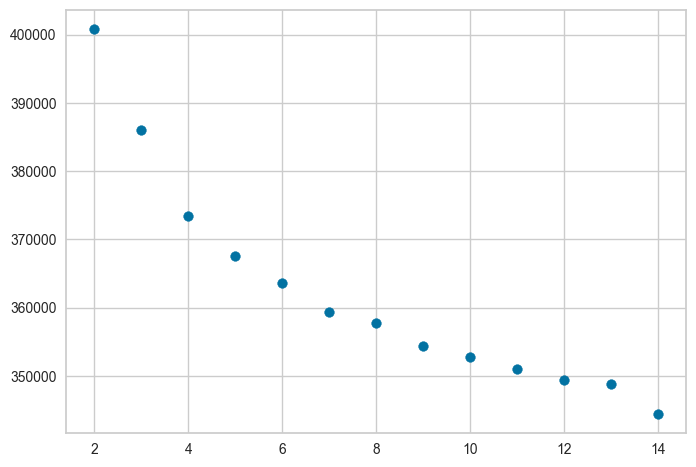

In [13]:
k_max = 15

bic = []
for k in range(2, k_max):
    gmm = GaussianMixture(n_components=k, init_params='kmeans', n_init=3)
    gmm.fit(data_reduced)
    bic.append(gmm.bic(data_reduced))
bic = np.array(bic)

plt.scatter(range(2, k_max), bic)
plt.show()

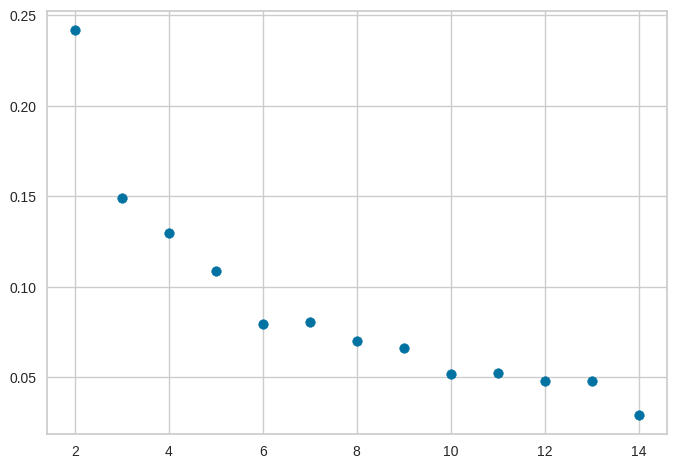

In [ ]:
k_max = 15

silhouette = []
for k in range(2, k_max):
    gmm = GaussianMixture(n_components=k, init_params='kmeans', n_init=3)
    clusters_gmm = gmm.fit_predict(data_reduced)
    silhouette.append( silhouette_score(data_reduced, clusters_gmm, metric='euclidean') )
silhouette = np.array(silhouette)

plt.scatter(range(2, k_max), silhouette)
plt.show()

In [14]:
K=2
gmm = GaussianMixture(n_components=K, n_init=3)
clusters_gmm = gmm.fit_predict(data_reduced)

In [15]:
from scipy.spatial.distance import cdist
from matplotlib.patches import Ellipse

In [16]:
def draw_ellipse(mean, covariance, alpha, ax, col='#CCCCCC'):
    """Draw an ellipse with a given position and covariance"""    
    # Convert covariance to principal axes
    U, s, Vt = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2 * np.sqrt(s)

    # Draw the Ellipse
    ax.add_patch(Ellipse(mean, 4*width, 4*height, angle=angle, alpha=alpha, fc=col))

In [17]:
def plotGMM(gmm, data, n_clusters=6):
    gmm.fit(data)
    clusters_gmm = gmm.predict(data)
    
    ax = plt.gca()
    ax.axis('equal')
    cmap = plt.get_cmap('Set3', n_clusters)
    
    # plot the input data
    ax.scatter(data[:, 0], data[:, 1], c=clusters_gmm, s=1, linewidths=1, cmap=cmap)
    
    #w_factor = 0.2 / gmm.weights_.max()
    for i in range(n_clusters):
        mean = gmm.means_[i,:2]
        covariance = gmm.covariances_[i,:2,:2]
        w = gmm.weights_[i]
        draw_ellipse(mean, covariance, w, ax, cmap.colors[i])

IndexError: index 3 is out of bounds for axis 0 with size 3

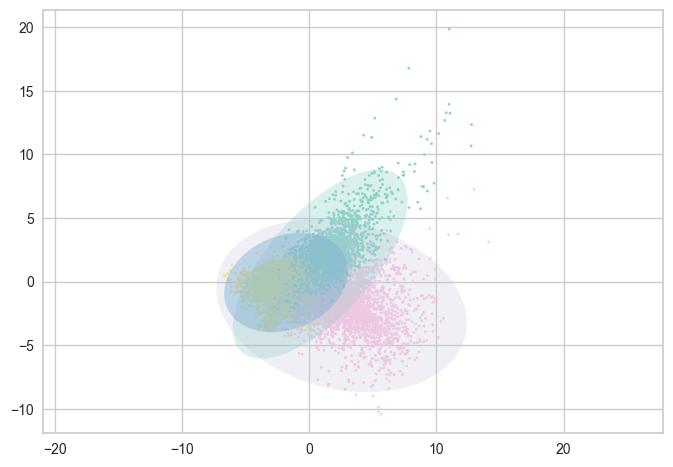

In [18]:
K =3
gmm = GaussianMixture(n_components=K, init_params='kmeans')

plotGMM(gmm, data_reduced)